# Sequence Length Comparison and Generalization

Single notebook workflow:
1. Run sequence-length benchmark and save results to disk.
2. Load results from disk.
3. Provide plots and tables comparing performance, latency, and memory usage across different sequence lengths and models.

In [1]:
from pathlib import Path

from IPython.display import display
from pfns.utils import get_default_device
from pfns.experiments.model_benchmarks.hashing import single_model_hash

from pfns.experiments.model_benchmarks.analysis import (
    add_normalized_comparison_metrics,
    add_numeric_buckets,
    compute_mean_rank_tables,
)
from pfns.experiments.model_benchmarks.constants import (
    DEFAULT_BUCKET_BINS,
    DEFAULT_BUCKET_LABELS,
)
from pfns.experiments.model_benchmarks.evaluation import evaluate_models_over_seqlens
from pfns.experiments.model_benchmarks.fixed_batches import resolve_fixed_batches
from pfns.experiments.model_benchmarks.io import (
    SEQ_LEN_REQUIRED_FILES,
    download_results_bundle_from_wandb,
    load_results_bundle,
    make_bundle_path,
    make_model_artifact_name,
    sanitize_wandb_artifact_component,
    save_results_bundle,
    upload_results_bundle_to_wandb,
)
from pfns.experiments.model_benchmarks.model_registry import (
    MODEL_FAMILIES,
    get_autocast_models_from_registry,
    get_forward_models_from_registry,
    get_models_from_families,
    get_models_from_names,
    get_all_models,
)
from pfns.experiments.model_benchmarks.models import load_models_for_benchmark
from pfns.experiments.model_benchmarks.path_utils import build_repo_output_root
from pfns.experiments.model_benchmarks.plotting import build_model_style_map, plot_curves_from_df
from pfns.experiments.model_benchmarks.workflows import (
    alias_single_model_seq_len_bundle,
    build_seq_len_run_metadata,
    merge_seq_len_model_results,
    seq_len_bundle_is_compatible,
    single_model_seq_len_result_from_bundle,
)

EXPERIMENT = {
    "name": "seq_len_comparison",
    "num_classes": 5,
    "num_features": 10,
    "num_test_samples": 100,
    "num_repetitions": 500,
    "data_generation_seed": 42,
    "use_warmup_iters": False,
    "print_timing": False,
    "seqlen_list": [250, 500, 750, 1_000, 2_000, 4_000, 8_000, 16_000, 32_000, 64_000, 128_000],
}

WANDB = {
    "enabled": True,
    "artifact_name": "seq_len_comparison",
    "overwrite": False,
    "entity": "icl_arch",
    "project": "seq_len_exp",
    "batch_artifact_name": "seq_len_batches",
    "batch_project": "seq_len_batch_cache",
}

OUTPUT_ROOT = build_repo_output_root(Path.cwd(), "seq_len")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Results are stored in: {OUTPUT_ROOT}")
print(f"Available model families: {list(MODEL_FAMILIES)}")

# Model selection:


# -> All models
# models_to_compare = get_all_models()

# -> All fla models
# models_to_compare = get_models_from_families(["fla_models"])

# -> Equal Param models 
# models_to_compare = get_models_from_families(["equal_params"])

# -> Transformer masking experiments
# models_to_compare = get_models_from_families(["transformer_masked"])

# models_to_compare = get_models_from_families(["equal_params"])
#models_to_compare = get_models_from_names(["Oracle_Hidden_State_DeltaNet_Comb_ST_new_base", "subsampled:DeltaNet_Comb_ST_3K",  "subsampled:Transformer_Comb_ST_3K","equal_params:Transformer_Comb_ST", "subsampled:DeltaNet_Comb_ST"])

# -> specific family
models_to_compare = get_models_from_families(["linear_batch_delta"])
models_to_compare.update(get_models_from_names(["Linear_Attention_Non_Causal"]))


# models_to_compare = get_models_from_names([
#     "Oracle_Hidden_State_DeltaNet_Comb_ST_state_init", 
#     "Oracle_Hidden_State_DeltaNet_Comb_ST",
#     "Oracle_Hidden_State_GLA_Comb_ST",
#     "Oracle_Hidden_State_Linear_Attention_Non_Causal",
#     #"Oracle_Hidden_State_Linear_Attention_Non_Causal_new_base",
#     "Linear_Attention_Non_Causal", 
#     # "Softmax_Transformer",
#     ]
# )


# Gating comparision
# models_to_compare = get_models_from_names([
#     "mimetic:GLA_Comb_ST_Ref",
#     "mimetic:GLA_Comb_ST_Open_Gates",
#     "Linear_Attention_Causal_Comb_ST",
#     ]
# )

# State passing comparision
# models_to_compare = get_models_from_names([
#     "State_Passing_GLA_Comb_ST",
#     "GLA_Comb_ST",
#     ]
# )


device = get_default_device()
print(f"Using device: {device}")

expected_run_metadata = build_seq_len_run_metadata(experiment=EXPERIMENT, device=device)

precomputed_batches = resolve_fixed_batches(
    experiment=EXPERIMENT,
    output_root=OUTPUT_ROOT,
    default_device=device,
    wandb=WANDB,
)
print(f"Using {len(precomputed_batches)} fixed batches for this experiment.")


/home/david/miniconda3/envs/icl_arch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Results are stored in: /home/david/ICL-Architectures/exp_outputs/seq_len
Available model families: ['transformer', 'kda', 'gla', 'deltanet', 'oracle_hidden_state', 'deltanet_size_changes', 'gated_deltanet', 'gated_deltanet_seq_len_changes', 'mamba2', 'linear_attention', 'linear_batch_delta', 'based', 'equal_params', 'transformer_masked', 'deltanet_high_seq_len', 'deltanet_added_regularization', 'deltanet_finetuned', 'mimetic_initialization', 'subsampled', 'state_passing', 'fla_models', 'other']
Using device: cuda:0
Loaded fixed batches from local cache: /home/david/ICL-Architectures/exp_outputs/seq_len/fixed_batches/seq_len_comparison_d3cb13a14226f5a5
Using 500 fixed batches for this experiment.


## Running the sequence-length benchmark

In [2]:
results_by_model = {}
model_bundle_paths = {}

if WANDB["enabled"] and WANDB["overwrite"]:
    print("WANDB overwrite=True: skipping per-model download and forcing rerun.")


for model_name, model_config in models_to_compare.items():
    model_hash = single_model_hash(
        model_name=model_name,
        model_config=model_config,
        experiment_payload=EXPERIMENT,
    )
    model_artifact_name = make_model_artifact_name(
        base_artifact_name=WANDB["artifact_name"],
        model_name=model_name,
        model_hash=model_hash,
    )

    reused_cached_result = False
    if WANDB["enabled"] and not WANDB["overwrite"]:
        cached_bundle_path = download_results_bundle_from_wandb(
            artifact_name=model_artifact_name,
            entity=WANDB["entity"],
            project=WANDB["project"],
            download_root=OUTPUT_ROOT / "wandb_model_cache",
            required_files=SEQ_LEN_REQUIRED_FILES,
        )
        if cached_bundle_path is not None:
            cached_bundle = load_results_bundle(cached_bundle_path)
            cached_bundle_for_model, aliased_from = alias_single_model_seq_len_bundle(
                cached_bundle,
                target_model_name=model_name,
            )
            if seq_len_bundle_is_compatible(
                cached_bundle_for_model,
                model_name=model_name,
                expected_metadata=expected_run_metadata,
            ):
                results_by_model[model_name] = single_model_seq_len_result_from_bundle(
                    cached_bundle_for_model,
                    model_name=model_name,
                )
                model_bundle_paths[model_name] = cached_bundle_path
                reused_cached_result = True
                if aliased_from is not None and aliased_from != model_name:
                    print(
                        f"Reused cached W&B result for {model_name} from stored label "
                        f"{aliased_from}: {cached_bundle_path}"
                    )
                else:
                    print(f"Reused cached W&B result for {model_name}: {cached_bundle_path}")
            else:
                print(
                    f"Cached artifact for {model_name} is incompatible with "
                    "this run metadata. Rerunning model."
                )

    if reused_cached_result:
        continue

    print(f"Running benchmark for model: {model_name}")
    models, configs = load_models_for_benchmark({model_name: model_config}, device=device)
    model_results = evaluate_models_over_seqlens(
        models=models,
        configs=configs,
        seqlen_list=EXPERIMENT["seqlen_list"],
        num_features=EXPERIMENT["num_features"],
        num_classes=EXPERIMENT["num_classes"],
        number_of_test_samples=EXPERIMENT["num_test_samples"],
        number_of_repetitions=EXPERIMENT["num_repetitions"],
        use_warmup_iters=EXPERIMENT["use_warmup_iters"],
        print_timing=EXPERIMENT["print_timing"],
        autocast_models=get_autocast_models_from_registry(
            {model_name: model_config},
            device=device,
        ),
        device=device,
        data_generation_seed=EXPERIMENT["data_generation_seed"],
        subsample_dataset_size=model_config.get("subsample_dataset_size"),
        progress_desc=f"{model_name} progress",
        forward_models=get_forward_models_from_registry({model_name: model_config}),
        precomputed_batches=precomputed_batches,
    )
    results_by_model[model_name] = model_results

    model_bundle_path = make_bundle_path(
        OUTPUT_ROOT,
        f"{EXPERIMENT['name']}_{sanitize_wandb_artifact_component(model_name)}",
    )
    save_results_bundle(
        model_results,
        model_bundle_path,
        experiment=EXPERIMENT,
        include_raw_torch=True,
    )
    model_bundle_paths[model_name] = model_bundle_path
    print(f"Saved per-model bundle for {model_name}: {model_bundle_path}")

    if WANDB["enabled"]:
        artifact_ref = upload_results_bundle_to_wandb(
            model_bundle_path,
            artifact_name=model_artifact_name,
            entity=WANDB["entity"],
            project=WANDB["project"],
            run_name=(
                f"{EXPERIMENT['name']}_{sanitize_wandb_artifact_component(model_name)}_"
                f"{model_hash}"
            ),
            metadata={
                "experiment": EXPERIMENT,
                "model_name": model_name,
                "model_config": model_config,
                "model_hash": model_hash,
                "run_metadata": model_results.get("metadata", {}),
            },
        )
        print(f"Uploaded per-model artifact for {model_name}: {artifact_ref}")

merged_output = merge_seq_len_model_results(
    results_by_model=results_by_model,
    expected_run_metadata=expected_run_metadata,
    model_names=list(models_to_compare.keys()),
    experiment=EXPERIMENT,
    model_bundle_paths=model_bundle_paths,
)

results = merged_output["results"]
metric_df = merged_output["metric_df"]
timing_df = merged_output["timing_df"]
memory_df = merged_output["memory_df"]
bundle_metadata = merged_output["bundle_metadata"]


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/david/.netrc.
wandb:   6 of 6 files downloaded.  


Reused cached W&B result for Linear_Batch_Delta: /home/david/ICL-Architectures/exp_outputs/seq_len/wandb_model_cache


wandb:   6 of 6 files downloaded.  


Reused cached W&B result for Linear_Attention_Non_Causal: /home/david/ICL-Architectures/exp_outputs/seq_len/wandb_model_cache


## Load benchmark results

In [3]:
if "results" not in globals():
    raise RuntimeError("No in-memory merged results found. Run the benchmark cell first.")

print("Using in-memory merged results from per-model artifacts/runs.")

print("Bundle metadata:")
display(bundle_metadata)

print("metric_df shape:", metric_df.shape)
print("timing_df shape:", timing_df.shape)
print("memory_df shape:", memory_df.shape)

display(metric_df.head())


Using in-memory merged results from per-model artifacts/runs.
Bundle metadata:


{'schema_version': 1,
 'experiment': {'name': 'seq_len_comparison',
  'num_classes': 5,
  'num_features': 10,
  'num_test_samples': 100,
  'num_repetitions': 500,
  'data_generation_seed': 42,
  'use_warmup_iters': False,
  'print_timing': False,
  'seqlen_list': [250,
   500,
   750,
   1000,
   2000,
   4000,
   8000,
   16000,
   32000,
   64000,
   128000]},
 'run_metadata': {'seqlen_list': [250,
   500,
   750,
   1000,
   2000,
   4000,
   8000,
   16000,
   32000,
   64000,
   128000],
  'num_features': 10,
  'num_classes': 5,
  'number_of_test_samples': 100,
  'number_of_repetitions': 500,
  'device': 'cuda:0',
  'data_generation_seed': 42,
  'models': ['Linear_Batch_Delta', 'Linear_Attention_Non_Causal']},
 'row_counts': {'metric': 33000, 'timing': 33000, 'memory': 33000},
 'per_model_bundle_paths': {'Linear_Batch_Delta': '/home/david/ICL-Architectures/exp_outputs/seq_len/wandb_model_cache',
  'Linear_Attention_Non_Causal': '/home/david/ICL-Architectures/exp_outputs/seq_len/wa

metric_df shape: (33000, 5)
timing_df shape: (33000, 5)
memory_df shape: (33000, 5)


,model,metric,seqlen,rep,value
16500,Linear_Attention_Non_Causal,acc,250,0,0.38
16501,Linear_Attention_Non_Causal,acc,250,1,0.67
16502,Linear_Attention_Non_Causal,acc,250,2,0.74
16503,Linear_Attention_Non_Causal,acc,250,3,0.78
16504,Linear_Attention_Non_Causal,acc,250,4,0.76


# Performance, latency and memory curves.

Using all sequence lengths for downstream analyses.


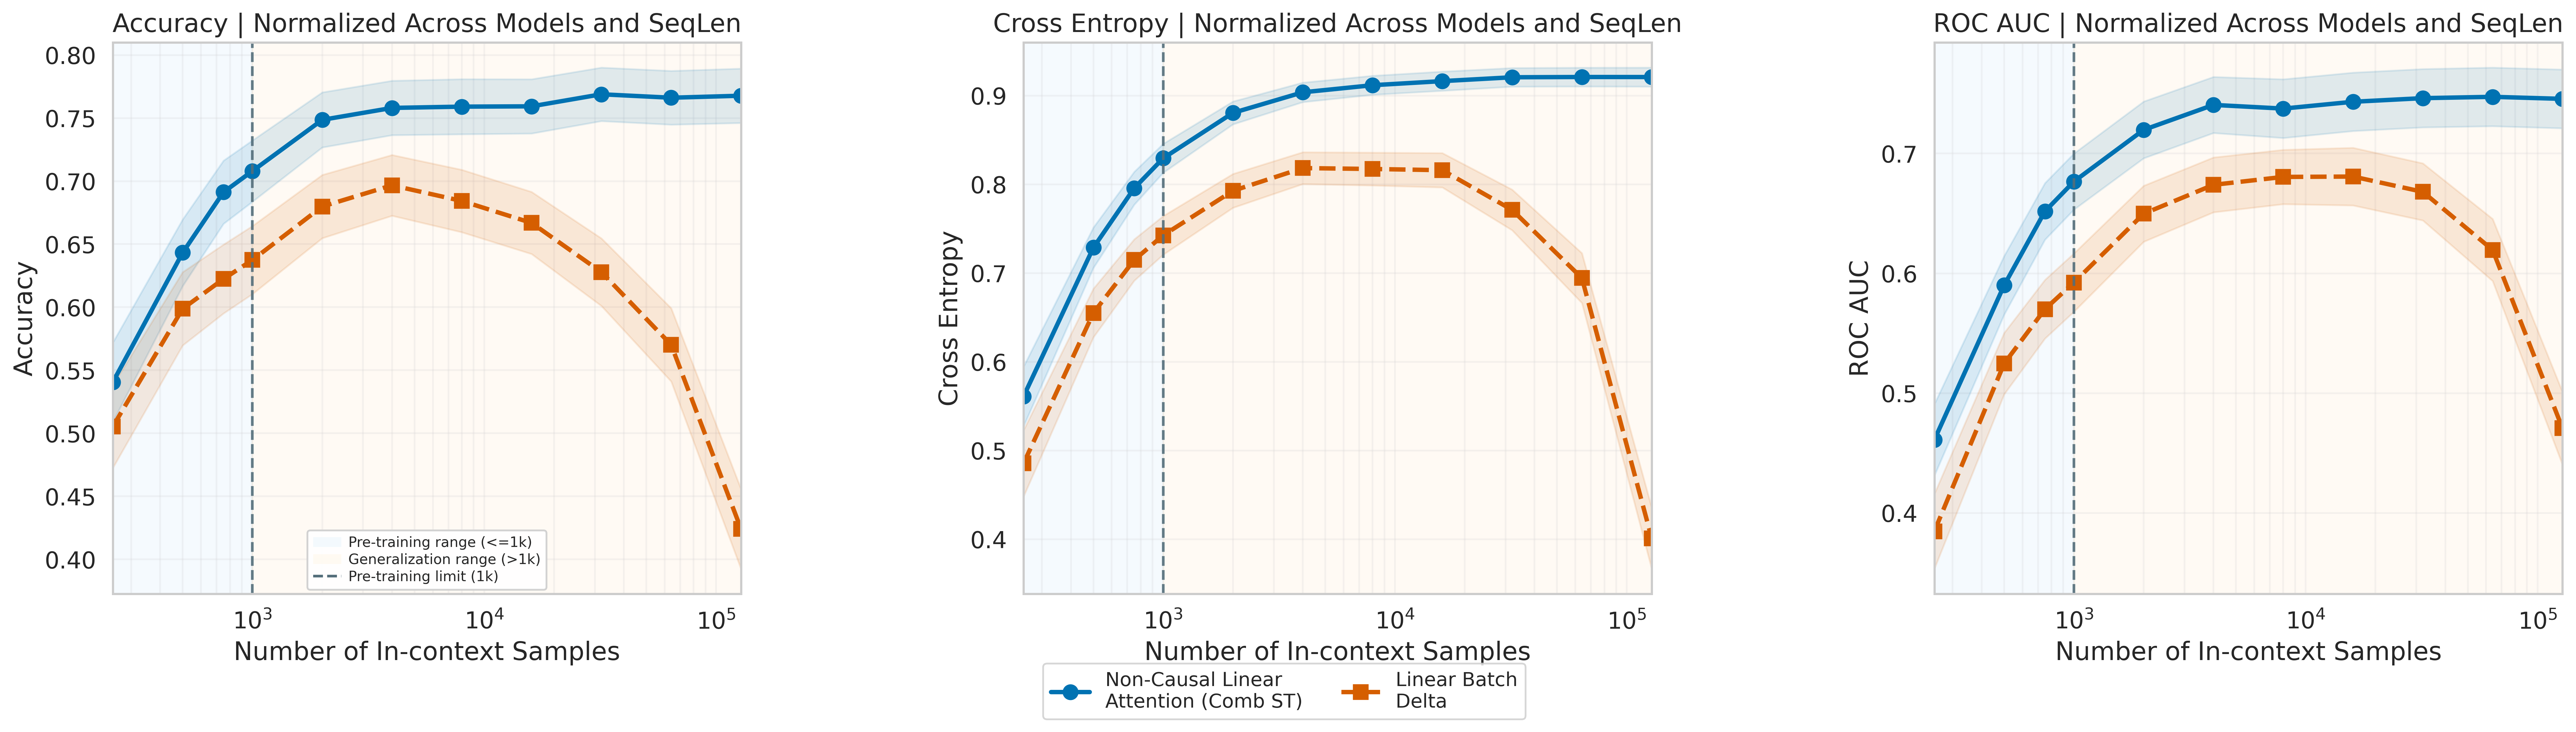

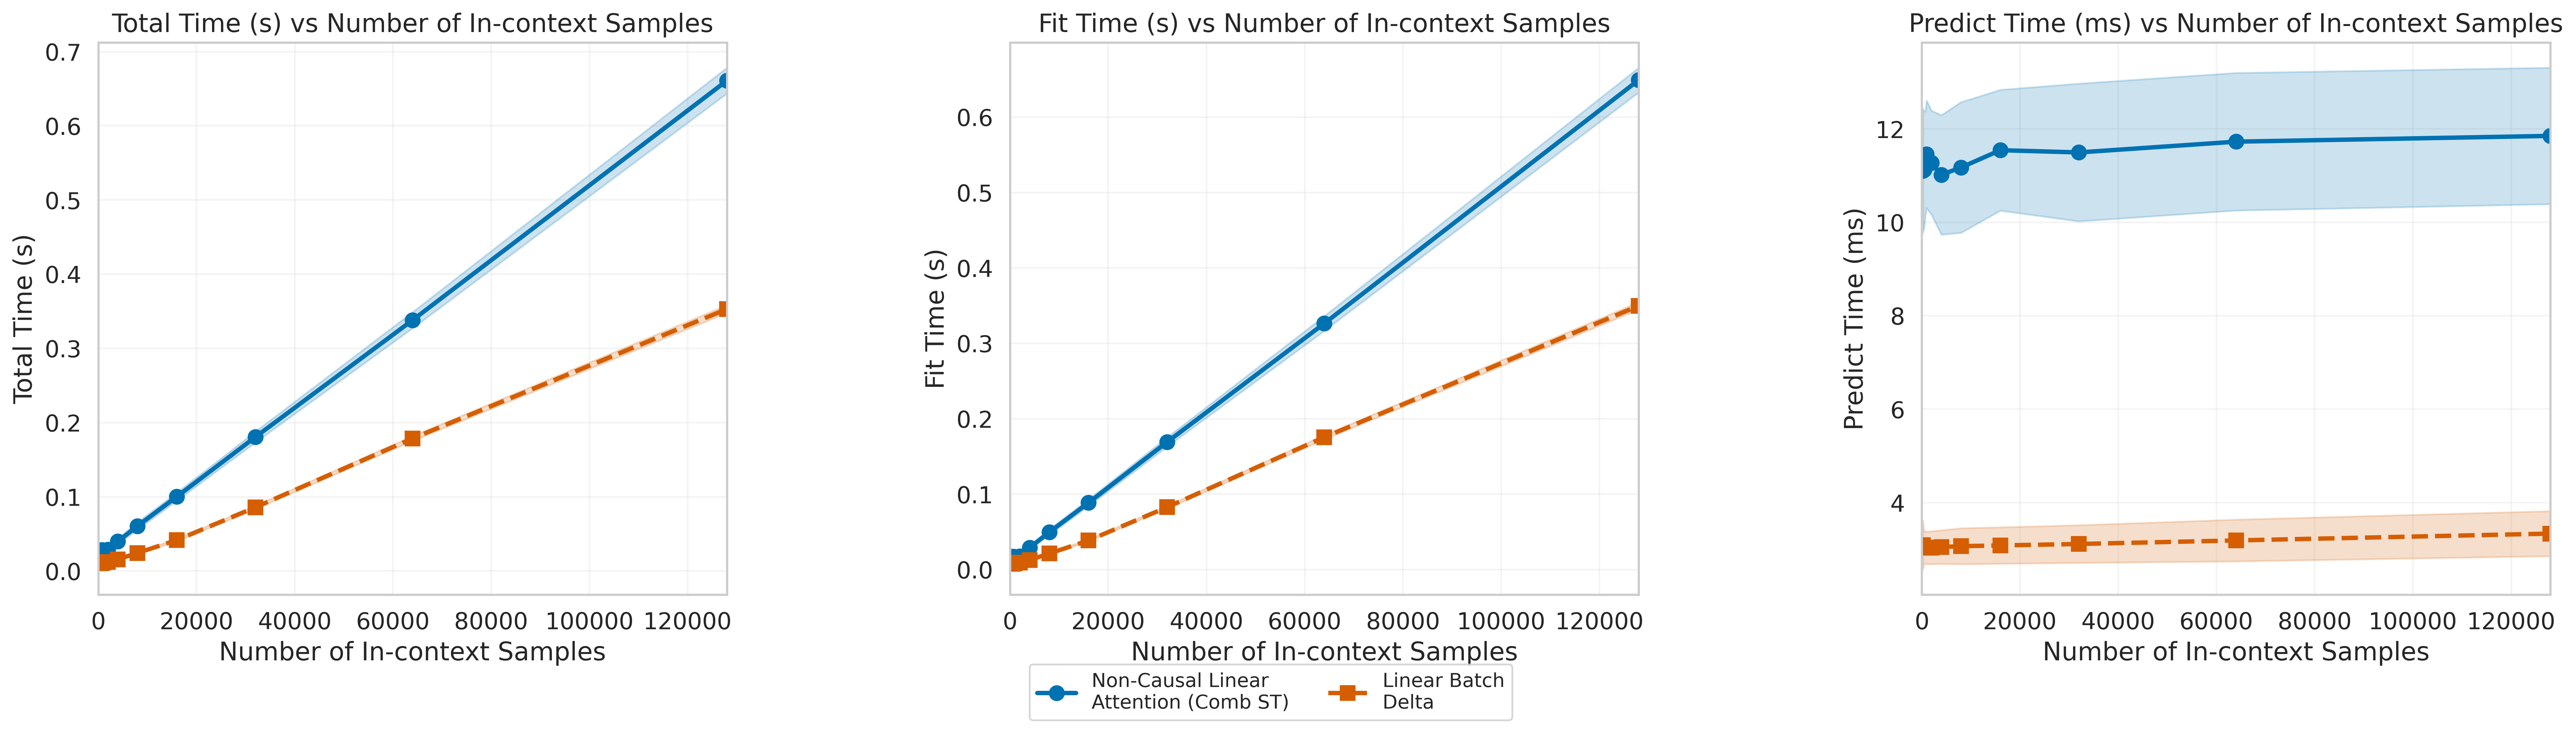

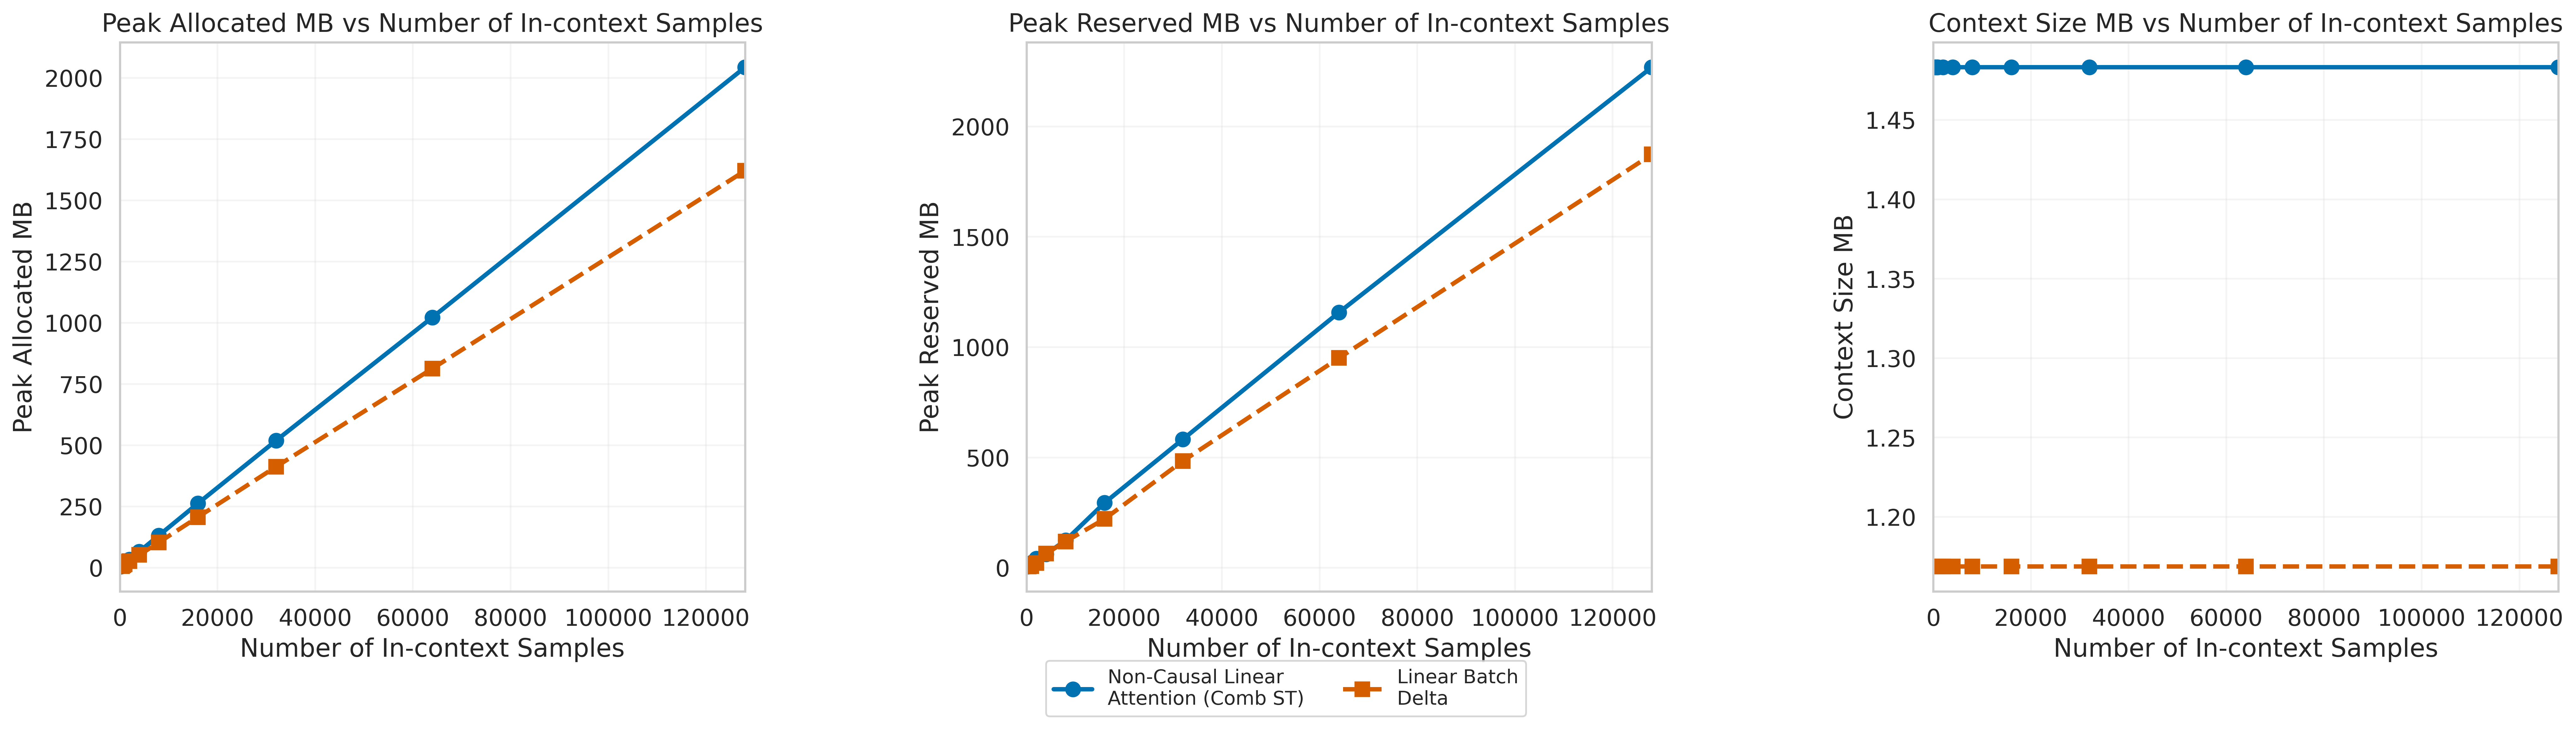

In [4]:
import numpy as np
import pandas as pd

BASE_METRIC_LABELS = {
    "acc": "Accuracy",
    "ce": "Cross Entropy",
    "roc_auc": "ROC AUC",
}
HIGHER_IS_BETTER_METRICS = {"acc", "roc_auc"}
NORMALIZATION_VIEWS = {
    # "metric_normalized_per_seqlen": {
    #     "prefix": "normalized_",
    #     "title": "Normalized Across Models at Fixed SeqLen",
    #     "group_cols": ("seqlen", "rep"),
    #     "normalization_scope": "comparison",
    # },
    "metric_normalized_global": {
        "prefix": "normalized_global_",
        "title": "Normalized Across Models and SeqLen",
        "group_cols": ("rep",),
        "normalization_scope": "group",
    },
    # "metric_normalized_per_model": {
    #     "prefix": "normalized_per_model_",
    #     "title": "Normalized Across SeqLen Within Model",
    #     "group_cols": ("model", "rep"),
    #     "normalization_scope": "group",
    # },
}

SEQ_LEN_ANALYSIS_MAX = None  # keep only seqlen <= cutoff for all downstream analyses.

def _filter_to_max_seqlen(df, *, max_seqlen=SEQ_LEN_ANALYSIS_MAX):
    if df is None:
        return df
    filtered = df.copy()
    if max_seqlen is not None:
        filtered = filtered[filtered["seqlen"] <= int(max_seqlen)].copy()
    return filtered

metric_analysis_df = _filter_to_max_seqlen(metric_df)
timing_analysis_df = _filter_to_max_seqlen(timing_df)
memory_analysis_df = _filter_to_max_seqlen(memory_df)

if SEQ_LEN_ANALYSIS_MAX is None:
    print("Using all sequence lengths for downstream analyses.")
else:
    print(f"Filtering downstream analyses to seqlen <= {int(SEQ_LEN_ANALYSIS_MAX)}.")

def build_normalized_metric_plot_df(df):
    plot_df = df.copy()
    for config in NORMALIZATION_VIEWS.values():
        plot_df = add_normalized_comparison_metrics(
            plot_df,
            metric_keys={
                metric: (f"{config['prefix']}{metric}", f"{config['title']}: {label}")
                for metric, label in BASE_METRIC_LABELS.items()
            },
            higher_is_better_metrics=HIGHER_IS_BETTER_METRICS,
            group_cols=config["group_cols"],
            normalization_scope=config["normalization_scope"],
            normalized_prefix=config["prefix"],
        )
    return plot_df

metric_plot_df = build_normalized_metric_plot_df(metric_analysis_df)

NORMALIZED_HIGHER_IS_BETTER = {
    f"{config['prefix']}{metric}"
    for config in NORMALIZATION_VIEWS.values()
    for metric in HIGHER_IS_BETTER_METRICS
}

SEQ_LEN_GENERALIZATION_PLOT_MODE = "individual_runs"
SEQ_LEN_GENERALIZATION_RUN_ALPHA = 0.07
SEQ_LEN_GENERALIZATION_DISTRIBUTION_ALPHA = 0.3
SEQ_LEN_GENERALIZATION_DISTRIBUTION_WIDTH_FRAC = 0.4
PLOT_SPECS = {
    "metric_raw": list(BASE_METRIC_LABELS.items()),
    **{
        panel_name: [
            (f"{config['prefix']}{metric}", label)
            for metric, label in BASE_METRIC_LABELS.items()
        ]
        for panel_name, config in NORMALIZATION_VIEWS.items()
    },
    "metric_rank": list(BASE_METRIC_LABELS.items()),
    "timing": [
        ("forward_time_ms", "Total Time (ms)"),
        ("fit_time_ms", "Fit Time (ms)"),
        ("predict_time_ms", "Predict Time (ms)"),
    ],
    "memory": [
        ("peak_allocated_mb", "Peak Allocated MB"),
        ("peak_reserved_mb", "Peak Reserved MB"),
        ("context_size_mb", "Context Size MB"),
    ],
}

PLOT_PANEL_CONFIGS = [ # error_style can be "bars" or "band"
    # ("metric_raw", metric_plot_df, 
    #     {"log_x": True, 
    #      "log_y": False, 
    #      "plot_mode": SEQ_LEN_GENERALIZATION_PLOT_MODE, 
    #      "run_alpha": SEQ_LEN_GENERALIZATION_RUN_ALPHA, 
    #      "distribution_alpha": SEQ_LEN_GENERALIZATION_DISTRIBUTION_ALPHA,
    #      "distribution_width_frac": SEQ_LEN_GENERALIZATION_DISTRIBUTION_WIDTH_FRAC,
    #      "show_run_lines": True,
    #      "distribution_style": "none", #"half_violin",
    #      "title_suffix": " | Raw vs Number of In-context Samples",
    #      "error_bars": "ci95", "error_style": "band",
    #     }
    # ),
    *[
        (
            panel_name,
            metric_plot_df,
            {
                "log_x": True,
                "log_y": False,
                # "plot_mode": SEQ_LEN_GENERALIZATION_PLOT_MODE,
                # "run_alpha": SEQ_LEN_GENERALIZATION_RUN_ALPHA,
                "distribution_alpha": SEQ_LEN_GENERALIZATION_DISTRIBUTION_ALPHA,
                "distribution_width_frac": SEQ_LEN_GENERALIZATION_DISTRIBUTION_WIDTH_FRAC,
                "show_run_lines": False,
                "distribution_style": "half_violin",
                "title_suffix": f" | {config['title']}",
                "value_ylim": (-0.05, 1.05),
                "error_bars": "ci95", "error_style": "band",
            },
        )
        for panel_name, config in NORMALIZATION_VIEWS.items()
    ],
    ("timing", timing_analysis_df, {"log_x": False, "log_y": False, "show_std": True, "seconds": ["forward_time_ms", "fit_time_ms"], "title_suffix": " vs Number of In-context Samples"}),
    ("memory", memory_analysis_df, {"log_x": False, "log_y": False, "gigabytes": False, "title_suffix": " vs Number of In-context Samples"}),
]

MODEL_LEGEND_LAYOUT = "bottom" # bottom or right

TABLE_PANEL_CONFIGS = [
    ("Performance", metric_plot_df, {"value_fmt": "{:.4f}", "cmap": "Greens_r"}),
    ("Timing", timing_analysis_df, {}),
    ("Memory", memory_analysis_df, {}),
]

def _prepare_plot_panel(df, specs, *, seconds=False, gigabytes=False):
    plot_df = df.copy()
    plot_specs = list(specs)
    seconds_metrics = {metric for metric, _ in plot_specs} if seconds is True else set(seconds or [])
    if seconds_metrics:
        plot_df = plot_df.copy()
        mask = plot_df["metric"].astype(str).isin(seconds_metrics)
        plot_df.loc[mask, "value"] = plot_df.loc[mask, "value"] / 1000.0
        plot_specs = [
            (metric, label.replace("(ms)", "(s)")) if metric in seconds_metrics else (metric, label)
            for metric, label in plot_specs
        ]
    if gigabytes:
        plot_df = plot_df.copy()
        plot_df["value"] = plot_df["value"] / 1024.0
        plot_specs = [(metric, label.replace("MB", "GB")) for metric, label in plot_specs]
    return plot_df, plot_specs

def plot_panel(df, specs, *, value_col="value", show_std=False, error_bars=None, error_style="bars", plot_mode="aggregate", run_alpha=0.35, distribution_alpha=None, distribution_width_frac=0.18, show_run_lines=True, distribution_style="half_violin", log_x=False, log_y=False, invert_y=False, seconds=False, gigabytes=False, title_suffix="", model_legend_layout=MODEL_LEGEND_LAYOUT, value_ylim=None, style_map_override=None):
    plot_df, plot_specs = _prepare_plot_panel(df, specs, seconds=seconds, gigabytes=gigabytes)
    fig, axes = plot_curves_from_df(
        plot_df,
        specs=plot_specs,
        style_map=style_map if style_map_override is None else style_map_override,
        x_col="seqlen",
        value_col=value_col,
        x_label="Number of In-context Samples",
        title_suffix=title_suffix,
        show_std=show_std,
        error_bars=error_bars,
        error_style=error_style,
        plot_mode=plot_mode,
        run_alpha=run_alpha,
        distribution_alpha=distribution_alpha,
        distribution_width_frac=distribution_width_frac,
        show_run_lines=show_run_lines,
        distribution_style=distribution_style,
        log_x=log_x,
        log_y=log_y,
        invert_y=invert_y,
        model_legend_layout=model_legend_layout,
    )
    if value_ylim is not None and axes is not None:
        for ax in axes:
            ax.set_ylim(*value_ylim)
    return fig, axes

def _display_pivot_by_metric(df, *, panel_name: str, pivot_col: str, value_col: str = "value", value_fmt: str = "{:.3f}", cmap: str = "Blues_r"):
    if df.empty:
        print(f"No {panel_name} data available.")
        return

    for metric in sorted(df["metric"].unique()):
        print(f"{panel_name} | {metric}")
        table = df[df["metric"] == metric].pivot_table(
            index="model",
            columns=pivot_col,
            values=value_col,
            observed=True,
        )
        display(table.style.format(value_fmt).background_gradient(cmap=cmap, axis=None))

def display_panel_tables(df, *, panel_name: str, value_fmt: str = "{:.3f}", cmap: str = "Blues_r"):
    if df.empty:
        print(f"No {panel_name} data available.")
        return

    print(f"=== {panel_name}: Mean by model ===")
    overall = (
        df.groupby(["model", "metric"], observed=True)["value"]
        .mean()
        .reset_index()
        .pivot_table(index="model", columns="metric", values="value", observed=True)
        .sort_index()
    )
    display(overall.style.format(value_fmt).background_gradient(cmap=cmap, axis=None))

    bucket_df = add_numeric_buckets(
        df,
        value_col="seqlen",
        bucket_col="bucket",
        bins=DEFAULT_BUCKET_BINS,
        labels=DEFAULT_BUCKET_LABELS,
    )
    print(f"=== {panel_name}: Mean by sequence-length bucket ===")
    _display_pivot_by_metric(bucket_df, panel_name=panel_name, pivot_col="bucket", value_col="value", value_fmt=value_fmt, cmap=cmap)

    print(f"=== {panel_name}: Mean by sequence length ===")
    _display_pivot_by_metric(df, panel_name=panel_name, pivot_col="seqlen", value_col="value", value_fmt=value_fmt, cmap=cmap)

present_models = metric_plot_df["model"].astype(str).unique().tolist()
ordered_models = [name for name in get_all_models() if name in set(present_models)]
ordered_models.extend(name for name in present_models if name not in ordered_models)
style_map = build_model_style_map(ordered_models)

for panel_name, df, opts in PLOT_PANEL_CONFIGS:
    plot_panel(df, PLOT_SPECS[panel_name], **opts)


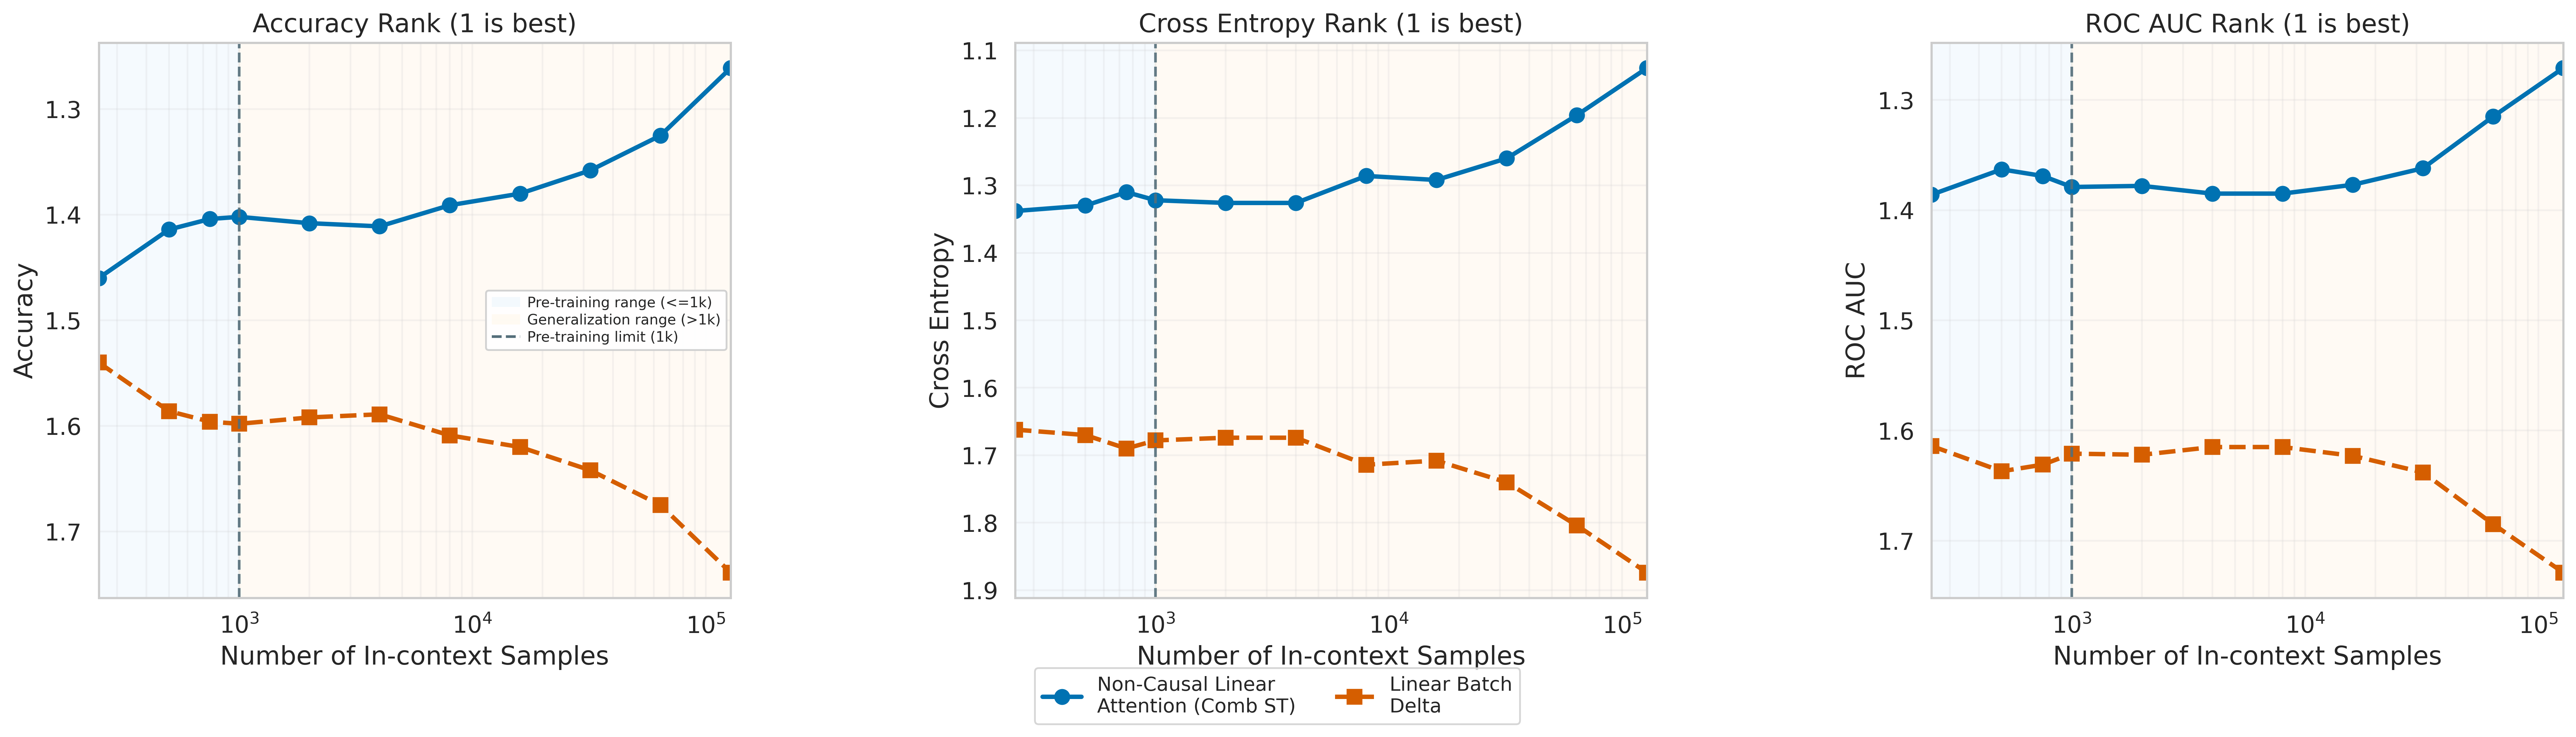

(<Figure size 8400x2400 with 3 Axes>,
 [<Axes: title={'center': 'Accuracy Rank (1 is best)'}, xlabel='Number of In-context Samples', ylabel='Accuracy'>,
  <Axes: title={'center': 'Cross Entropy Rank (1 is best)'}, xlabel='Number of In-context Samples', ylabel='Cross Entropy'>,
  <Axes: title={'center': 'ROC AUC Rank (1 is best)'}, xlabel='Number of In-context Samples', ylabel='ROC AUC'>])

In [5]:
rank_tables = compute_mean_rank_tables(
    metric_plot_df,
    x_col="seqlen",
    higher_is_better_metrics={"acc", "roc_auc", *NORMALIZED_HIGHER_IS_BETTER},
)

plot_panel(
    rank_tables["x_ranks"],
    PLOT_SPECS["metric_rank"],
    value_col="rank",
    log_x=True,
    invert_y=True,
    title_suffix=" Rank (1 is best)",
)


# Tabels with the detailed results for each model and sequence length.

## Performance, Timing and Memory Tables

Summary tables by model, by sequence-length bucket, and by exact sequence length.


In [6]:
for panel_name, df, kwargs in TABLE_PANEL_CONFIGS:
    display_panel_tables(df, panel_name=panel_name, **kwargs)


=== Performance: Mean by model ===


metric,acc,ce,normalized_global_acc,normalized_global_ce,normalized_global_roc_auc,roc_auc
model,,,,,,
Linear_Attention_Non_Causal,0.6585,0.8311,0.7192,0.8446,0.6872,0.7788
Linear_Batch_Delta,0.6393,1.2881,0.6104,0.7009,0.5923,0.7705


=== Performance: Mean by sequence-length bucket ===
Performance | acc


bucket,<=500,501-1K,1K-2K,2K-5K,5K-10K,10K+
model,,,,,,
Linear_Attention_Non_Causal,0.6455,0.6567,0.6612,0.6622,0.6626,0.6632
Linear_Batch_Delta,0.6406,0.6492,0.6539,0.6553,0.6513,0.6229


Performance | ce


...

seqlen,250,500,750,1000,2000,4000,8000,16000,32000,64000,128000
model,,,,,,,,,,,
Linear_Attention_Non_Causal,1.483,1.483,1.483,1.483,1.483,1.483,1.483,1.483,1.483,1.483,1.483
Linear_Batch_Delta,1.169,1.169,1.169,1.169,1.169,1.169,1.169,1.169,1.169,1.169,1.169


Memory | peak_allocated_mb


seqlen,250,500,750,1000,2000,4000,8000,16000,32000,64000,128000
model,,,,,,,,,,,
Linear_Attention_Non_Causal,5.476,9.464,14.043,18.230,33.863,66.238,131.924,262.830,519.485,1022.483,2043.479
Linear_Batch_Delta,24.852,7.092,10.198,14.251,27.543,52.447,103.649,206.920,412.765,813.575,1620.821


Memory | peak_reserved_mb


seqlen,250,500,750,1000,2000,4000,8000,16000,32000,64000,128000
model,,,,,,,,,,,
Linear_Attention_Non_Causal,6.000,8.000,10.000,22.000,42.000,62.000,123.960,294.660,582.000,1158.000,2268.600
Linear_Batch_Delta,14.488,6.160,9.964,6.856,21.760,63.980,118.964,221.424,483.848,951.344,1873.396


## Performance rank table

In [7]:
overall_ranks = rank_tables["overall_ranks"]
bucket_ranks = rank_tables["bucket_ranks"]
x_ranks = rank_tables["x_ranks"]

for metric in sorted(metric_plot_df["metric"].unique()):
    print(f"=== Mean rank for {metric} (lower is better) ===")
    overall = (
        overall_ranks[overall_ranks["metric"] == metric]
        .sort_values("rank")
        .drop(columns="metric")
        .reset_index(drop=True)
    )
    display(overall.style.format({"rank": "{:.2f}"}).background_gradient(subset=["rank"], cmap="Greens_r"))

print("=== Mean rank by bucket ===")
_display_pivot_by_metric(
    bucket_ranks,
    panel_name="Rank by bucket",
    pivot_col="bucket",
    value_col="rank",
    value_fmt="{:.2f}",
    cmap="Greens_r",
)

print("=== Mean rank by sequence length ===")
_display_pivot_by_metric(
    x_ranks,
    panel_name="Rank by sequence length",
    pivot_col="seqlen",
    value_col="rank",
    value_fmt="{:.2f}",
    cmap="Greens_r",
)

=== Mean rank for acc (lower is better) ===


,model,rank
0,Linear_Attention_Non_Causal,1.23
1,Linear_Batch_Delta,1.77


=== Mean rank for ce (lower is better) ===


,model,rank
0,Linear_Attention_Non_Causal,1.13
1,Linear_Batch_Delta,1.87


=== Mean rank for normalized_global_acc (lower is better) ===


...

seqlen,250,500,750,1000,2000,4000,8000,16000,32000,64000,128000
model,,,,,,,,,,,
Linear_Attention_Non_Causal,1.66,1.67,1.69,1.68,1.67,1.67,1.71,1.71,1.74,1.80,1.87
Linear_Batch_Delta,1.34,1.33,1.31,1.32,1.33,1.33,1.29,1.29,1.26,1.20,1.13


Rank by sequence length | normalized_global_roc_auc


seqlen,250,500,750,1000,2000,4000,8000,16000,32000,64000,128000
model,,,,,,,,,,,
Linear_Attention_Non_Causal,1.39,1.36,1.37,1.38,1.38,1.39,1.39,1.38,1.36,1.31,1.27
Linear_Batch_Delta,1.61,1.64,1.63,1.62,1.62,1.61,1.61,1.62,1.64,1.69,1.73


Rank by sequence length | roc_auc


seqlen,250,500,750,1000,2000,4000,8000,16000,32000,64000,128000
model,,,,,,,,,,,
Linear_Attention_Non_Causal,1.39,1.36,1.37,1.38,1.38,1.39,1.39,1.38,1.36,1.31,1.27
Linear_Batch_Delta,1.61,1.64,1.63,1.62,1.62,1.61,1.61,1.62,1.64,1.69,1.73


## Setting Comparison Across Sequence-Length Generalization

Paired gain and Wilcoxon-Holm significance tests for canonical settings (`Comb_MT`, `Comb_ST`, `Int_ST`, `Int_MT`) across all lengths, pre-training range, and generalization range.


In [8]:
import pandas as pd

from pfns.experiments.model_benchmarks.comparison_analysis import run_comparison_analysis
from pfns.experiments.model_benchmarks.setting_analysis import get_setting_preprocess
from pfns.experiments.model_benchmarks.wilcoxon_cd_diagram import graph_ranks, wilcoxon_holm_from_wide

SEQ_METRIC_DIRECTION = {
    "acc": True,
    "roc_auc": True,
    "ce": False,
}

SEQ_METRIC_LABELS = {
    "acc": "Accuracy",
    "roc_auc": "ROC AUC",
    "ce": "Cross Entropy",
}

SETTING_GENERALIZATION_ANALYSIS = {
    "metric": "roc_auc",  # one of: acc, roc_auc, ce
    "target_labels": ["Comb_MT", "Comb_ST", "Int_ST", "Int_MT"],
    "reference_label": "Int_MT",
    "error_bars": "ci95",  # std or ci95
    "pair_by_rep": True,
    "seqlen_cutoff": 1_000,
    "wilcoxon_alpha": 0.05,
}

if "metric_analysis_df" not in globals() or metric_analysis_df.empty:
    raise RuntimeError("No metric_analysis_df found. Run the plotting/configuration cell first.")

metric = SETTING_GENERALIZATION_ANALYSIS["metric"]
if metric not in SEQ_METRIC_DIRECTION:
    raise ValueError(f"Unsupported metric {metric!r}. Choose from {list(SEQ_METRIC_DIRECTION)}")

metric_slice = metric_analysis_df[metric_analysis_df["metric"] == metric].copy()
if metric_slice.empty:
    raise RuntimeError(f"No rows found for metric {metric!r} in metric_analysis_df.")

target_labels = list(dict.fromkeys(SETTING_GENERALIZATION_ANALYSIS["target_labels"]))
try:
    pre = get_setting_preprocess(results_df=metric_slice, target_settings=target_labels)
except RuntimeError as exc:
    print(f"Skipping setting comparison: {exc}")
else:
    comparison_base = pre["filtered_results"].copy()
    presence = pre["presence"].reindex(columns=target_labels, fill_value=False).sort_index()
    eligible_model_types = pre["eligible_model_types"]

    print("Canonical setting availability by model type:")
    display(presence)
    print("Eligible model types (all requested settings available):", eligible_model_types)

    cutoff = int(SETTING_GENERALIZATION_ANALYSIS["seqlen_cutoff"])
    range_slices = [
        ("all_lengths", comparison_base),
        (f"pretraining_le_{cutoff}", comparison_base[comparison_base["seqlen"] <= cutoff].copy()),
        (f"generalization_gt_{cutoff}", comparison_base[comparison_base["seqlen"] > cutoff].copy()),
    ]

    higher_is_better = SEQ_METRIC_DIRECTION[metric]
    pair_cols = ["model_type", "seqlen", "rep"] if SETTING_GENERALIZATION_ANALYSIS["pair_by_rep"] else ["model_type", "seqlen"]

    for range_name, range_df in range_slices:
        print(f"\n=== Setting comparison: {range_name} ===")
        if range_df.empty:
            print("Skipping: no rows in this range.")
            continue

        available_settings = [
            label for label in target_labels if label in set(range_df["setting"].astype(str).unique())
        ]
        if len(available_settings) < 2:
            print(f"Skipping: need at least two settings in range, found {available_settings}.")
            continue

        reference_label = SETTING_GENERALIZATION_ANALYSIS["reference_label"]
        if reference_label not in available_settings:
            label_means = (
                range_df.groupby("setting", observed=True)["value"].mean().reindex(available_settings)
            )
            reference_label = label_means.idxmax() if higher_is_better else label_means.idxmin()

        try:
            analysis = run_comparison_analysis(
                comparison_results=range_df,
                metric_col="value",
                metric_label=SEQ_METRIC_LABELS[metric],
                compare_col="setting",
                target_labels=available_settings,
                pair_cols=pair_cols,
                higher_better=higher_is_better,
                reference_label=reference_label,
                unit="seqlen",
                error_bars=SETTING_GENERALIZATION_ANALYSIS["error_bars"],
                comparison_label="setting",
                include_boxplot=True,
                include_pairwise_tables=True,
                include_cd_diagram=True,
                wilcoxon_alpha=SETTING_GENERALIZATION_ANALYSIS["wilcoxon_alpha"],
                empty_error_message=(
                    "No complete paired rows found across requested settings for this length range. "
                    "Try pair_by_rep=True, or evaluate more model types."
                ),
            )
        except RuntimeError as exc:
            print(f"Skipping {range_name}: {exc}")
            continue

        p_values, mean_ranks, n_pairs = wilcoxon_holm_from_wide(
            metric_wide_complete=analysis["metric_wide_complete"],
            target_labels=analysis["target_labels"],
            higher_better=higher_is_better,
            alpha=SETTING_GENERALIZATION_ANALYSIS["wilcoxon_alpha"],
        )

        print(f"Metric: {SEQ_METRIC_LABELS[metric]} ({metric})")
        print(f"Reference setting: {analysis['gain']['reference_label']}")
        print(f"Compared settings: {analysis['target_labels']}")
        print(f"Pairing columns: {pair_cols}")
        print(f"Complete paired rows used: {analysis['n_complete_pairs']}")
        print(f"Wilcoxon/Holm paired rows used: {int(n_pairs)}")

        print("Setting means:")
        display(analysis["gain"]["label_means"].to_frame("mean"))

        print("\nPaired gain summary by setting (positive = better than reference):")
        display(
            analysis["gain"]["gain_summary"].style.format(
                {
                    "mean_gain": "{:+.5f}",
                    "std_gain": "{:.5f}",
                    "sem_gain": "{:.5f}",
                    "ci95": "{:.5f}",
                    "ci95_low": "{:+.5f}",
                    "ci95_high": "{:+.5f}",
                    "n_pairs": "{:.0f}",
                    "share_pairs_better": "{:.1%}",
                }
            ).background_gradient(subset=["mean_gain"], cmap="RdYlGn")
        )

        print("\nPairwise Wilcoxon p-values with Holm significance flag:")
        p_value_table = pd.DataFrame(
            p_values,
            columns=["setting_a", "setting_b", "p_raw", "significant_holm"],
        ).sort_values("p_raw", ascending=True, kind="stable")
        display(
            p_value_table.style.format({"p_raw": "{:.6f}"}).apply(
                lambda col: ["background-color: #c7f9cc" if bool(v) else "" for v in col],
                subset=["significant_holm"],
            )
        )

        print("Average ranks used in the CD diagram (1 = best):")
        rank_table = mean_ranks.reindex(analysis["target_labels"]).to_frame("average_rank")
        display(rank_table.sort_values("average_rank").style.format({"average_rank": "{:.3f}"}))

        if analysis["pairwise"] is not None:
            print("Pairwise mean gain matrix (row vs column):")
            display(analysis["pairwise"]["pairwise_mean"].style.format("{:+.4f}").background_gradient(cmap="RdYlGn", axis=None))
            print("Pairwise 95% CI half-width matrix:")
            display(analysis["pairwise"]["pairwise_ci95"].style.format("{:.4f}").background_gradient(cmap="Blues", axis=None))
            print("Pairwise significance proxy (95% CI excludes zero):")
            display(analysis["pairwise"]["pairwise_sig"])

        for fig_key in ["gain_barh", "gain_boxplot", "wilcoxon_cd"]:
            if fig_key in analysis["figures"]:
                fig, ax = analysis["figures"][fig_key]
                if fig_key == "wilcoxon_cd":
                    ax.set_title(
                        f"Wilcoxon/Holm comparison diagram ({SEQ_METRIC_LABELS[metric]}, unit=seqlen, range={range_name})",
                        y=0.98,
                    )
                display(fig)
                plt.close(fig)

model ignored: Linear_Attention_Non_Causal
model ignored: Linear_Batch_Delta
Skipping setting comparison: No canonical Comb/Int setting models were found.


## Equal-Parameter Comparison Across Sequence-Length Generalization

Paired gain and Wilcoxon-Holm significance tests for registry-defined equal-parameter models across all lengths, pre-training range, and generalization range.


In [9]:
import matplotlib.pyplot as plt
import pandas as pd

from pfns.experiments.model_benchmarks.model_registry import get_models_from_families
from pfns.experiments.model_benchmarks.comparison_analysis import run_comparison_analysis
from pfns.experiments.model_benchmarks.wilcoxon_cd_diagram import wilcoxon_holm_from_wide

if "SEQ_METRIC_DIRECTION" not in globals() or "SEQ_METRIC_LABELS" not in globals():
    raise RuntimeError(
        "Missing shared metric metadata. Run the 'Setting Comparison Across Sequence-Length Generalization' code cell first."
    )

EQUAL_PARAMS_GENERALIZATION_ANALYSIS = {
    "metric": "roc_auc",  # one of: acc, roc_auc, ce
    "unit": "seqlen",
    "reference_label": None,  # auto-select best mean in each range
    "error_bars": "ci95",
    "pair_by_rep": True,
    "seqlen_cutoff": 1_000,
    "wilcoxon_alpha": 0.05,
}

if "metric_analysis_df" not in globals() or metric_analysis_df.empty:
    raise RuntimeError("No metric_analysis_df found. Run the plotting/configuration cell first.")

metric = EQUAL_PARAMS_GENERALIZATION_ANALYSIS["metric"]
if metric not in SEQ_METRIC_DIRECTION:
    raise ValueError(f"Unsupported metric {metric!r}. Choose from {list(SEQ_METRIC_DIRECTION)}")

metric_slice = metric_analysis_df[metric_analysis_df["metric"] == metric].copy()
if metric_slice.empty:
    raise RuntimeError(f"No rows found for metric {metric!r} in metric_analysis_df.")

registered_equal_models = list(get_models_from_families(["equal_params"]).keys())
available_models = set(metric_slice["model"].astype(str).unique())
target_models = [m for m in registered_equal_models if m in available_models]

print(f"Equal-params models available in this run: {target_models}")
if len(target_models) < 2:
    print("Skipping equal-params comparison: need at least two equal-params models in metric_analysis_df.")
else:
    comparison_base = metric_slice[metric_slice["model"].isin(target_models)].copy()
    cutoff = int(EQUAL_PARAMS_GENERALIZATION_ANALYSIS["seqlen_cutoff"])
    range_slices = [
        ("all_lengths", comparison_base),
        (f"pretraining_le_{cutoff}", comparison_base[comparison_base["seqlen"] <= cutoff].copy()),
        (f"generalization_gt_{cutoff}", comparison_base[comparison_base["seqlen"] > cutoff].copy()),
    ]

    higher_is_better = SEQ_METRIC_DIRECTION[metric]
    pair_cols = ["seqlen", "rep"] if EQUAL_PARAMS_GENERALIZATION_ANALYSIS["pair_by_rep"] else ["seqlen"]

    for range_name, range_df in range_slices:
        print(f"\n=== Equal-params comparison: {range_name} ===")
        if range_df.empty:
            print("Skipping: no rows in this range.")
            continue

        available_in_range = [
            m for m in target_models if m in set(range_df["model"].astype(str).unique())
        ]
        if len(available_in_range) < 2:
            print(f"Skipping: need at least two models in range, found {available_in_range}.")
            continue

        model_means = range_df.groupby("model", observed=True)["value"].mean().reindex(available_in_range)
        reference_label = EQUAL_PARAMS_GENERALIZATION_ANALYSIS["reference_label"]
        if reference_label is None or reference_label not in available_in_range:
            reference_label = model_means.idxmax() if higher_is_better else model_means.idxmin()

        try:
            analysis = run_comparison_analysis(
                comparison_results=range_df,
                metric_col="value",
                metric_label=SEQ_METRIC_LABELS[metric],
                compare_col="model",
                target_labels=available_in_range,
                pair_cols=pair_cols,
                higher_better=higher_is_better,
                reference_label=reference_label,
                unit=EQUAL_PARAMS_GENERALIZATION_ANALYSIS["unit"],
                error_bars=EQUAL_PARAMS_GENERALIZATION_ANALYSIS["error_bars"],
                comparison_label="model",
                include_boxplot=False,
                include_pairwise_tables=True,
                include_cd_diagram=True,
                wilcoxon_alpha=EQUAL_PARAMS_GENERALIZATION_ANALYSIS["wilcoxon_alpha"],
                empty_error_message=(
                    "No complete paired rows found across equal-params models for this length range. "
                    "Try pair_by_rep=True, or evaluate more equal-params models."
                ),
            )
        except RuntimeError as exc:
            print(f"Skipping {range_name}: {exc}")
            continue

        p_values, mean_ranks, n_pairs = wilcoxon_holm_from_wide(
            metric_wide_complete=analysis["metric_wide_complete"],
            target_labels=analysis["target_labels"],
            higher_better=higher_is_better,
            alpha=EQUAL_PARAMS_GENERALIZATION_ANALYSIS["wilcoxon_alpha"],
        )

        print(f"Metric: {SEQ_METRIC_LABELS[metric]} ({metric})")
        print(f"Reference model: {analysis['gain']['reference_label']}")
        print(f"Compared models: {analysis['target_labels']}")
        print(f"Pairing columns: {pair_cols}")
        print(f"Complete paired rows used: {analysis['n_complete_pairs']}")
        print(f"Wilcoxon/Holm paired rows used: {int(n_pairs)}")

        print("Equal-params model means:")
        display(model_means.sort_values(ascending=not higher_is_better).to_frame("mean"))

        print("\nPaired gain summary by model (positive = better than reference):")
        display(
            analysis["gain"]["gain_summary"].style.format(
                {
                    "mean_gain": "{:+.5f}",
                    "std_gain": "{:.5f}",
                    "sem_gain": "{:.5f}",
                    "ci95": "{:.5f}",
                    "ci95_low": "{:+.5f}",
                    "ci95_high": "{:+.5f}",
                    "n_pairs": "{:.0f}",
                    "share_pairs_better": "{:.1%}",
                }
            ).background_gradient(subset=["mean_gain"], cmap="RdYlGn")
        )

        print("\nPairwise Wilcoxon p-values with Holm significance flag:")
        p_value_table = pd.DataFrame(
            p_values,
            columns=["model_a", "model_b", "p_raw", "significant_holm"],
        ).sort_values("p_raw", ascending=True, kind="stable")
        display(
            p_value_table.style.format({"p_raw": "{:.6f}"}).apply(
                lambda col: ["background-color: #c7f9cc" if bool(v) else "" for v in col],
                subset=["significant_holm"],
            )
        )

        print("Average ranks used in the CD diagram (1 = best):")
        rank_table = mean_ranks.reindex(analysis["target_labels"]).to_frame("average_rank")
        display(rank_table.sort_values("average_rank").style.format({"average_rank": "{:.3f}"}))

        if analysis["pairwise"] is not None:
            print("Pairwise mean gain matrix (row vs column):")
            display(analysis["pairwise"]["pairwise_mean"].style.format("{:+.4f}").background_gradient(cmap="RdYlGn", axis=None))
            print("Pairwise 95% CI half-width matrix:")
            display(analysis["pairwise"]["pairwise_ci95"].style.format("{:.4f}").background_gradient(cmap="Blues", axis=None))
            print("Pairwise significance proxy (95% CI excludes zero):")
            display(analysis["pairwise"]["pairwise_sig"])

        for fig_key in ["gain_barh", "wilcoxon_cd"]:
            if fig_key in analysis["figures"]:
                fig, ax = analysis["figures"][fig_key]
                if fig_key == "wilcoxon_cd":
                    ax.set_title(
                        f"Wilcoxon/Holm comparison diagram ({SEQ_METRIC_LABELS[metric]}, unit={EQUAL_PARAMS_GENERALIZATION_ANALYSIS['unit']}, range={range_name})",
                        y=0.98,
                    )
                display(fig)
                plt.close(fig)

Equal-params models available in this run: []
Skipping equal-params comparison: need at least two equal-params models in metric_analysis_df.


## Setup-Averaged Sequence-Length Curves

Average performance, latency, and memory curves across all models that share the same canonical setup (`Comb_MT`, `Comb_ST`, `Int_ST`, `Int_MT`).


In [10]:
import re

SETUP_PATTERN = re.compile(r"_(Comb_MT|Comb_ST|Int_MT|Int_ST)(?:_|$)")
SETUP_DISPLAY_NAMES = {
    "Int_MT": "Interleaved\nMulti Target",
    "Comb_ST": "Combined\nSingle Target",
    "Int_ST": "Interleaved\nSingle Target",
    "Comb_MT": "Combined\nMulti Target",
}


def _extract_setup_label(model_name: str) -> str | None:
    match = SETUP_PATTERN.search(str(model_name))
    if match is None:
        return None
    return SETUP_DISPLAY_NAMES.get(match.group(1), match.group(1))


def build_setup_averaged_df(df):
    if df is None or df.empty:
        return df.copy() if df is not None else df

    required_cols = {"model", "metric", "seqlen", "rep", "value"}
    missing = sorted(required_cols - set(df.columns))
    if missing:
        raise RuntimeError(f"Dataframe is missing required columns for setup averaging: {missing}")

    out = df.copy()
    out["setup"] = out["model"].map(_extract_setup_label)
    out = out[out["setup"].notna()].copy()
    if out.empty:
        return out

    averaged = (
        out.groupby(["setup", "metric", "seqlen", "rep"], observed=True)["value"]
        .mean()
        .reset_index()
        .rename(columns={"setup": "model"})
    )
    return averaged


setup_metric_df = build_setup_averaged_df(metric_analysis_df)
setup_timing_df = build_setup_averaged_df(timing_analysis_df)
setup_memory_df = build_setup_averaged_df(memory_analysis_df)

if setup_metric_df is None or setup_metric_df.empty:
    print("No canonical setup labels found in loaded models; skipping setup-averaged plots.")
else:
    setup_metric_plot_df = build_normalized_metric_plot_df(setup_metric_df)

    setup_order = [name for name in SETUP_DISPLAY_NAMES.values() if name in set(setup_metric_df["model"].unique())]
    setup_style_map = build_model_style_map(setup_order)

    setup_plot_panel_configs = [
        ("metric", setup_metric_plot_df, {"log_x": True, "error_bars": "ci95", "error_style": "band", "title_suffix": " (Setup average) vs Number of In-context Samples"}),
        *[
            (
                panel_name,
                setup_metric_plot_df,
                {
                    "log_x": True,
                    "error_bars": "ci95",
                    "error_style": "band",
                    "title_suffix": f" (Setup average) | {config['title']}",
                },
            )
            for panel_name, config in NORMALIZATION_VIEWS.items()
        ],
        ("timing", setup_timing_df, {"show_std": True, "log_x": False, "title_suffix": " (Setup average) vs Number of In-context Samples"}),
        ("memory", setup_memory_df, {"log_x": False, "title_suffix": " (Setup average) vs Number of In-context Samples"}),
    ]

    for panel_name, df, opts in setup_plot_panel_configs:
        plot_panel(
            df,
            PLOT_SPECS["metric_raw"] if panel_name == "metric" else PLOT_SPECS[panel_name],
            style_map_override=setup_style_map,
            **opts,
        )


    setup_rank_tables = compute_mean_rank_tables(setup_metric_df, x_col="seqlen")
    plot_panel(
        setup_rank_tables["x_ranks"],
        PLOT_SPECS["metric_raw"],
        value_col="rank",
        log_x=True,
        invert_y=True,
        title_suffix=" Rank (1 is best, setup average)",
        style_map_override=setup_style_map,
    )



No canonical setup labels found in loaded models; skipping setup-averaged plots.
